# Setup

In [1]:
import requests
import time
import pandas as pd
import fasttext
language_model = fasttext.load_model("lid.176.bin")
import html
import re
import matplotlib.pyplot as plt

# Data Collection

I think Arctic Shift is more suitable than PullPush because it can return up to 1000 posts per call depending on server capacity (requiring fewer API calls for pagination), and it also allows selecting specific fields so we only retrieve the data we actually need, which potentially reduces both response time and size.

In [5]:
def fetch_all_posts(subreddit, after, before):
    base_url = "https://arctic-shift.photon-reddit.com/api/posts/search"
    all_posts = [] # Create a list to store retrieved posts
    current_after = after # Initialize the starting point for pagination

    while True:
        # Define query parameters for the API request
        params = {
            "subreddit": subreddit,
            "after": current_after,
            "before": before,
            "limit": "auto",
            "sort": "asc",
            "fields": "id,title,selftext,author,author_fullname,created_utc,url" # Chosen fields
        }

        # Send GET request to the API
        response = requests.get(base_url, params=params)
        # If request fails, stop execution
        if response.status_code != 200:
            print("Request failed:", response.status_code)
            break

        # Print rate limit information (for monitoring)
        remaining = response.headers.get("X-RateLimit-Remaining")
        reset = response.headers.get("X-RateLimit-Reset")
        print(f"Rate limit remaining: {remaining}, resets at: {reset}")

        # Extract data from JSON response
        posts = response.json().get("data", [])

        # Empty response means no more posts to fetch, we exit the loop
        if not posts:
            break  

        # Add newly fetched posts to the main list
        all_posts.extend(posts)
        print(f"Fetched {len(all_posts)} posts so far...")

        # Use the last post's timestamp as the new starting point
        current_after = posts[-1]["created_utc"]

        time.sleep(0.25)  # To fully avoid hitting rate limits

    return all_posts

In [3]:
# Fetch posts from r/personalfinance for the year 2020
personalfinance_2020_posts = fetch_all_posts(
    subreddit="personalfinance",
    after="2020-01-01",
    before="2021-01-01"
)

print(f"Done! Total posts: {len(personalfinance_2020_posts)}")

Rate limit remaining: 1995, resets at: 6
Fetched 1000 posts so far...
Rate limit remaining: 1994, resets at: 6
Fetched 2000 posts so far...
Rate limit remaining: 1993, resets at: 5
Fetched 3000 posts so far...
Rate limit remaining: 1992, resets at: 5
Fetched 4000 posts so far...
Rate limit remaining: 1991, resets at: 4
Fetched 5000 posts so far...
Rate limit remaining: 1990, resets at: 3
Fetched 6000 posts so far...
Rate limit remaining: 1989, resets at: 3
Fetched 7000 posts so far...
Rate limit remaining: 1988, resets at: 2
Fetched 8000 posts so far...
Rate limit remaining: 1987, resets at: 2
Fetched 9000 posts so far...
Rate limit remaining: 1990, resets at: 37
Fetched 10000 posts so far...


KeyboardInterrupt: 

In [ ]:
# Convert to DataFrame and save as CSV
df_personalfinance_2020 = pd.DataFrame(personalfinance_2020_posts)
df_personalfinance_2020.to_csv("personalfinance_2020_before_cleaning.csv", index=False)

In [ ]:
# Fetch posts from r/personalfinance for the year 2025
personalfinance_2025_posts = fetch_all_posts(
    subreddit="personalfinance",
    after="2025-01-01",
    before="2026-01-01"
)

print(f"Done! Total posts: {len(personalfinance_2025_posts)}")

In [ ]:
# Convert to DataFrame and save as CSV
df_personalfinance_2025 = pd.DataFrame(personalfinance_2025_posts)
df_personalfinance_2025.to_csv("personalfinance_2025_before_cleaning.csv", index=False)

In [ ]:
# Fetch posts from r/finanzen for the year 2020
finanzen_2020_posts = fetch_all_posts(
    subreddit="finanzen",
    after="2020-01-01",
    before="2021-01-01"
)

print(f"Done! Total posts: {len(finanzen_2020_posts)}")

In [ ]:
# Convert to DataFrame and save as CSV
df_finanzen_2020 = pd.DataFrame(finanzen_2020_posts)
df_finanzen_2020.to_csv("finanzen_2020_before_cleaning.csv", index=False)

In [ ]:
# Fetch posts from r/finanzen for the year 2025
finanzen_2025_posts = fetch_all_posts(
    subreddit="finanzen",
    after="2025-01-01",
    before="2026-01-01"
)

print(f"Done! Total posts: {len(finanzen_2025_posts)}")

In [ ]:
# Convert to DataFrame and save as CSV
df_finanzen_2025 = pd.DataFrame(finanzen_2025_posts)
df_finanzen_2025.to_csv("finanzen_2025_before_cleaning.csv", index=False)

# Data Cleaning

In [2]:
df_personalfinance_2020 = pd.read_csv("personalfinance_2020_before_cleaning.csv")
df_personalfinance_2025 = pd.read_csv("personalfinance_2025_before_cleaning.csv")
df_finanzen_2020 = pd.read_csv("finanzen_2020_before_cleaning.csv")
df_finanzen_2025 = pd.read_csv("finanzen_2025_before_cleaning.csv")

## Quick preview of all datasets

In [3]:
df_personalfinance_2020.head(30)

,author,author_fullname,created_utc,id,selftext,title,url
0,throwawaydsadrenter,t2_5ccxoo7l,1577836895,eib0o9,I've lived in the same apartment for over 4 ye...,In apartment while house is being finished and...,https://www.reddit.com/r/personalfinance/comme...
1,skiboysteve,t2_o24ok,1577836915,eib0tz,My wife and I have three credit cards from the...,Does closing hardly used credit cards impact c...,https://www.reddit.com/r/personalfinance/comme...
2,[deleted],NaN,1577836941,eib114,[removed],What are some best books to invest in?,https://www.reddit.com/r/personalfinance/comme...
3,[deleted],NaN,1577837058,eib1xw,[deleted],Bank Account Locked For Fraud,https://www.reddit.com/r/personalfinance/comme...
4,[deleted],NaN,1577837197,eib34d,[deleted],Auto accident - Not my fault - Feels like I’m ...,https://www.reddit.com/r/personalfinance/comme...
5,forthehorns777,t2_38bz0erk,1577837590,eib64c,"Background: I'm 30 y/o, I have a stable job wi...","Have $25K saved, what is a low risk way to inv...",https://www.reddit.com/r/personalfinance/comme...
6,[deleted],NaN,1577837868,eib887,[deleted],Progressive won't pay out,https://www.reddit.com/r/personalfinance/comme...
7,[deleted],NaN,1577838203,eibapw,[deleted],New Job and Moving: need debt consolidation ad...,https://www.reddit.com/r/personalfinance/comme...
8,StillAsleep_,t2_ydgta,1577838393,eibc3a,I'm 18 years old and this summer I've worked j...,Teenager looking for investment advice,https://www.reddit.com/r/personalfinance/comme...
9,The-Sentinel,t2_8yc8c,1577838434,eibcfz,I work for a US based company that provided RS...,Underpaid tax for 2018 on investments. What sh...,https://www.reddit.com/r/personalfinance/comme...


In [4]:
df_personalfinance_2025.head(30)

,author,author_fullname,created_utc,id,selftext,title,url
0,Western_Ship_7103,t2_cacx72vu,1735689610,1hqr97r,Hi Personal Finance Reddit! I recently sold my...,Teaching teens to invest,https://www.reddit.com/r/personalfinance/comme...
1,Newmacriumuser,t2_2nkc3e5q,1735689767,1hqrb68,"Hello,\n\nLong story short, I set up a traditi...",Questions about 2024 & 25 Backdoor Roth conver...,https://www.reddit.com/r/personalfinance/comme...
2,Musketeer_1058,t2_icawqpzy9,1735689816,1hqrbpz,"Inherited IRA. What is best way, if any exist...",I have to take RMD from,https://www.reddit.com/r/personalfinance/comme...
3,mjkouris12,t2_aw66nas2,1735689973,1hqrddu,"For 2025, my fiancé and I are picking one book...",One book you’d recommend to someone newerish t...,https://www.reddit.com/r/personalfinance/comme...
4,SnooCats5250,t2_5y3mcas1,1735690067,1hqrech,Hear me out. If you are making out your 401k a...,Everyone bashing paying off your house early.,https://www.reddit.com/r/personalfinance/comme...
5,movingcantousa,t2_1f5eph1ch1,1735690141,1hqrf3a,[removed],21M moving from Canada to USA needing advice,https://www.reddit.com/r/personalfinance/comme...
6,movingcantousa,t2_1f5eph1ch1,1735690362,1hqrhfj,I’m a 21 year old university student moving fr...,21 year old moving from Canada to USA in need ...,https://www.reddit.com/r/personalfinance/comme...
7,Responsible_Okra_672,t2_bjjxnr9z,1735691196,1hqrqk8,"Good evening, \n\nMy husband is retired from t...",UTMA-What to do with it?,https://www.reddit.com/r/personalfinance/comme...
8,mstrlucky74,t2_125b21,1735691297,1hqrrl2,Hello All and thanks in advance So here's a sn...,Advice For Getting Pool,https://www.reddit.com/r/personalfinance/comme...
9,FistfulOfMemes,t2_52lmw6fk,1735691354,1hqrs5g,"This past weekend, I was rear-ended by an inat...","Car totaled, not at fault, what should I know/do?",https://www.reddit.com/r/personalfinance/comme...


In [5]:
df_finanzen_2020.head(30)

,author,author_fullname,created_utc,id,selftext,title,url
0,pedobuster00,t2_48vyk5mv,1577839539,eibkvz,Frohes neues! \n\nHabe gerade mit meinem Dad a...,Erfahrungen mit Konsumschulden,https://www.reddit.com/r/Finanzen/comments/eib...
1,hohlenmensch,t2_h31b0,1577872778,eigshj,NaN,Geldanlage: Wohin mit Ihrem Geld? - Zeit.de,https://www.zeit.de/wirtschaft/geldanlage/2019...
2,Doctor_Jeep,t2_ms284,1577884067,eii65s,NaN,Geldanlage: Frauen haben im Jahr 2019 das bess...,https://www.faz.net/aktuell/finanzen/meine-fin...
3,abe2912,t2_qsh1422,1577908915,eimxd0,NaN,CSU will ein kostenloses Basiskonto für alle,https://www.faz.net/aktuell/finanzen/csu-will-...
4,HumbleSplit9,t2_2f6h27w3,1577910492,ein9yz,"Hallo Leute,\nBin 20 und noch in der Ausbildun...",Auf Crash warten unsinnig? - Anfänger,https://www.reddit.com/r/Finanzen/comments/ein...
5,salttrail,t2_1gilblb,1577913083,einuwh,&#x200B;\n\nhttps://preview.redd.it/tf5uy4qgd8...,"[Budget] Software Developer 30M, Family",https://www.reddit.com/r/Finanzen/comments/ein...
6,R1a2g3n4a5r6o7k,t2_3qbfrbt1,1577913947,eio1oz,"Hey,\n\nMal ein etwas anderes Thema was aber s...",Wie finde ich Expat Stellen,https://www.reddit.com/r/Finanzen/comments/eio...
7,salttrail,t2_1gilblb,1577915495,eioe1n,"Hello all,\n\nIn my previous [post](https://ww...",Begginer investment plan,https://www.reddit.com/r/Finanzen/comments/eio...
8,marneusc,t2_5518edl8,1577919424,eip73t,"Guten Abend zusammen,\n\nIch lese einige Zeit ...","Xtrackers -> vanguard Sparplan, oder auf dem H...",https://www.reddit.com/r/Finanzen/comments/eip...
9,Rainer74,t2_4zjm90fi,1577919864,eipaoi,Beschäftige mich gerade mit Immobilien Kauf/Ve...,Unendliche Abschreibung von Immobilien ?!,https://www.reddit.com/r/Finanzen/comments/eip...


In [6]:
df_finanzen_2025.head(30)

,author,author_fullname,created_utc,id,selftext,title,url
0,Initial-Show-1051,t2_hn7c7t7vx,1735692162,1hqs0ds,Jedes Jahr das gleiche. Schon vor der Öffnung ...,Feuerwerk - Lieber den Anblick „schnorren“,https://www.reddit.com/r/Finanzen/comments/1hq...
1,masuhr,t2_dzuoboud,1735692567,1hqs4kp,"moin, hab jetzt mitte des jahres angefangen zu...",vorschläge bitte,https://i.redd.it/pne8hhs45aae1.jpeg
2,Raphoyer,t2_66ar2odo,1735693245,1hqsbk3,NaN,Direkt mit Profit ins neue Jahr gestartet 💪,https://i.redd.it/v0acaqc57aae1.jpeg
3,TravelWorld1510,t2_jyr07h49,1735694186,1hqsl2x,NaN,Deutschland kurz vor dem Finanzkollaps (Symbol...,https://i.redd.it/5wt5d85y9aae1.jpeg
4,Federal-Ear-2911,t2_1fsm006oo9,1735695269,1hqsw06,Ich würde gerne einen Vertriebler begleiten um...,Vertriebler begleiten 72160 und Umgebung,https://www.reddit.com/r/Finanzen/comments/1hq...
5,undercoverkangoroo,t2_akgnykfc,1735695560,1hqsyxs,[removed],Gme rebound,https://www.reddit.com/r/Finanzen/comments/1hq...
6,Avocadoodlydo,t2_b10v031n,1735695720,1hqt0iv,"Hallo zusammen,\n\nwir wollen unsere ETW verka...",Wohnung verkaufen aber noch ein Jahr weiter wo...,https://www.reddit.com/r/Finanzen/comments/1hq...
7,P_Abies,t2_1esq28kpkl,1735696560,1hqt8s9,"Servus,\n\nnach acht Jahren im Ausbildungsberu...",Aus dem Job an die Uni und zurück,https://i.redd.it/6ynkh290haae1.jpeg
8,vghgvbh,t2_4d418ye2,1735697308,1hqtg3h,Mal angenommen man möchte jetzt im Jahr 2025 d...,Was ist heutzutage die beste Lösung für einen ...,https://www.reddit.com/r/Finanzen/comments/1hq...
9,MiddleApprehensive87,t2_n1e2yd9t,1735698286,1hqtpht,"So liebe Carbonara-Esser, ich halte euch für a...",Bundestagswahl,https://www.reddit.com/r/Finanzen/comments/1hq...


## Missing Values and Short Posts

The selftext column represents the main content of each post.
I remove rows where selftext is missing (NaN) or contains placeholder values such as [deleted] or [removed], as these do not provide meaningful textual information for analysis.

Missing (NaN) values typically occur in posts that contain only non-textual content (e.g., images or videos), while [deleted] and [removed] typically indicate posts that have been removed either by users or moderators.

In [7]:
def drop_missing_and_placeholder_posts(df, dataset_name):
    initial_count = len(df)
    # Remove rows where selftext is missing (NaN)
    df = df.dropna(subset=["selftext"])
    # Remove rows where selftext contains placeholder values
    df = df[~df["selftext"].isin(["[deleted]", "[removed]"])]
    final_count = len(df)
    print(f"{dataset_name}: dropped {initial_count - final_count} rows, {final_count} remaining")
    return df

In [8]:
df_personalfinance_2020 = drop_missing_and_placeholder_posts(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = drop_missing_and_placeholder_posts(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = drop_missing_and_placeholder_posts(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = drop_missing_and_placeholder_posts(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: dropped 76828 rows, 105336 remaining
personalfinance_2025: dropped 33267 rows, 75668 remaining
finanzen_2020: dropped 2895 rows, 5138 remaining
finanzen_2025: dropped 9469 rows, 23813 remaining


I also verify that the title column contains no missing values, as it will be used alongside selftext.

In [9]:
print("personalfinance_2020:", df_personalfinance_2020["title"].isna().sum())
print("personalfinance_2025:", df_personalfinance_2025["title"].isna().sum())
print("finanzen_2020:", df_finanzen_2020["title"].isna().sum())
print("finanzen_2025:", df_finanzen_2025["title"].isna().sum())

personalfinance_2020: 0
personalfinance_2025: 0
finanzen_2020: 0
finanzen_2025: 0


And I also check the title column for any unexpected values that should not be there.

In [10]:
df_finanzen_2025["title"].value_counts()

title
Trade Republic                                                                          15
Sparplan                                                                                10
Hilfe                                                                                    9
Steuererklärung                                                                          7
Hauskauf                                                                                 6
                                                                                        ..
mit Vollmacht Tagesgeldkonto für Oma eröffnen                                            1
Budget für 2025                                                                          1
Bank zahlt Zins nicht                                                                    1
Kassensturz - Wie hat sich euer Net Worth 2025 entwickelt?                               1
Suche KI-Affines Investment welches nicht so stark auf physische Investitionen setzt

Now, I experiment with different length thresholds based on the combined length of title + selftext to identify short, low-information posts (since in some cases the main content or question is expressed in the title while the selftext is very short).
By inspecting posts below different thresholds, I aim to determine a reasonable cutoff point above which posts are likely to contain meaningful content.

In [11]:
# Create a new column for combined text length (title + selftext)
df_personalfinance_2020["combined_length"] = (
    df_personalfinance_2020["title"].str.len() +
    df_personalfinance_2020["selftext"].str.len()
)

# Filter posts with combined length threshold
short_posts = df_personalfinance_2020[df_personalfinance_2020["combined_length"] < 60]

print(short_posts["selftext"].value_counts())

selftext
.                                           4
Anyone have a mortgage with them?           1
What is the best way to save money?         1
Thanks.                                     1
How does tax work for day trader?           1
L                                           1
Conflicted.                                 1
[Edited]                                    1
My annual salary will                       1
Thank you everyone!                         1
What are good investments for 2-3 years?    1
Name: count, dtype: int64


After manually inspecting posts with a combined length below different thresholds across all four datasets (by opening the original posts via their URLs), I observed that a threshold of 60 characters provides a good balance. The majority of posts below this threshold contain little to no meaningful information. They are very short, low-effort, and many have even been removed by moderators due to insufficient content. Therefore, I use 60 characters as a cutoff threshold to filter out short posts.

In [12]:
# Function to remove posts with combined length below threshold
def drop_short_posts(df, dataset_name, threshold=60):
    # Create combined length column
    df["combined_length"] = df["title"].str.len() + df["selftext"].str.len()
    before = len(df)
    # Keep only posts above threshold
    df = df[df["combined_length"] >= threshold]
    after = len(df)
    print(f"{dataset_name}: dropped {before - after} rows, {after} remaining")
    return df

In [13]:
# Apply to all datasets
df_personalfinance_2020 = drop_short_posts(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = drop_short_posts(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = drop_short_posts(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = drop_short_posts(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: dropped 14 rows, 105322 remaining
personalfinance_2025: dropped 53 rows, 75615 remaining
finanzen_2020: dropped 7 rows, 5131 remaining
finanzen_2025: dropped 197 rows, 23616 remaining


## Deduplication

I combine the title and the selftext fields into a single column (full_text) to represent the complete textual content of each post. This combined field will be used in subsequent steps.

In [14]:
# Create a column that contains the full textual content of the post
def create_full_text(df):
    df["full_text"] = df["title"] + " " + df["selftext"]
    return df

In [15]:
df_personalfinance_2020 = create_full_text(df_personalfinance_2020)
df_personalfinance_2025 = create_full_text(df_personalfinance_2025)
df_finanzen_2020 = create_full_text(df_finanzen_2020)
df_finanzen_2025 = create_full_text(df_finanzen_2025)

We check the number of duplicated full_text entries in each dataset before applying deduplication.

In [16]:
# Check number of duplicate full_text entries in each dataset
print("personalfinance_2020:", df_personalfinance_2020["full_text"].duplicated().sum())
print("personalfinance_2025:", df_personalfinance_2025["full_text"].duplicated().sum())
print("finanzen_2020:", df_finanzen_2020["full_text"].duplicated().sum())
print("finanzen_2025:", df_finanzen_2025["full_text"].duplicated().sum())

personalfinance_2020: 162
personalfinance_2025: 237
finanzen_2020: 2
finanzen_2025: 67


To remove duplicated content, I drop duplicate rows based on the full_text column, keeping only the first occurrence of each post.

In [17]:
def drop_duplicates_full_text(df, dataset_name):
    before = len(df)
    # Keep first occurrence, drop the rest
    df = df.drop_duplicates(subset=["full_text"], keep="first")
    after = len(df)
    print(f"{dataset_name}: dropped {before - after} duplicate rows, {after} remaining")
    return df

In [18]:
df_personalfinance_2020 = drop_duplicates_full_text(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = drop_duplicates_full_text(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = drop_duplicates_full_text(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = drop_duplicates_full_text(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: dropped 162 duplicate rows, 105160 remaining
personalfinance_2025: dropped 237 duplicate rows, 75378 remaining
finanzen_2020: dropped 2 duplicate rows, 5129 remaining
finanzen_2025: dropped 67 duplicate rows, 23549 remaining


## Bot and Spam Detection

Several bot/spam filtering steps have already been addressed in previous stages. Deduplication removed posts with identical content, which captures spams and bots engaged in content repetition. Also, the short post filter and missing value dropping eliminated very short and low-information posts, which also removes many link-only or image-only bot posts. To further strengthen bot detection, I apply a post velocity filter to catch accounts posting at an implausibly high rate, a clear sign of automated behavior.

In [19]:
def apply_post_velocity_filter(df, dataset_name, threshold=30):
    
    # Convert to datetime
    df["created_datetime"] = pd.to_datetime(df["created_utc"], unit="s")

    # Create hourly time window
    df["created_hour"] = df["created_datetime"].dt.floor("h")

    # Count posts per user per hour
    hourly_counts = df.groupby(["author_fullname", "created_hour"]).size().reset_index(name="posts_per_hour")

    # Identify suspicious user-hour combinations
    suspicious_activity = hourly_counts[hourly_counts["posts_per_hour"] > threshold]

    # Identify suspicious accounts
    suspicious_accounts = suspicious_activity["author_fullname"].unique()

    # Get affected posts
    suspicious_posts = df[df["author_fullname"].isin(suspicious_accounts)]

    print(f"{dataset_name}:")
    print(f"Suspicious accounts: {len(suspicious_accounts)}")
    print(f"Posts from suspicious accounts: {len(suspicious_posts)}")

    # Drop posts from suspicious accounts
    df = df[~df["author_fullname"].isin(suspicious_accounts)]
    print(f"Remaining posts after filter: {len(df)}\n")

    # Drop the created columns
    df = df.drop(columns=["created_datetime", "created_hour"])

    return df

This function detects accounts with unusually high posting activity by counting the number of posts per user within hourly time windows. Accounts exceeding the defined threshold are flagged as suspicious, and all posts from these accounts are removed.

In [20]:
df_personalfinance_2020 = apply_post_velocity_filter(df_personalfinance_2020, "personalfinance_2020", threshold=5)
df_personalfinance_2025 = apply_post_velocity_filter(df_personalfinance_2025, "personalfinance_2025", threshold=5)
df_finanzen_2020 = apply_post_velocity_filter(df_finanzen_2020, "finanzen_2020", threshold=5)
df_finanzen_2025 = apply_post_velocity_filter(df_finanzen_2025, "finanzen_2025", threshold=5)

personalfinance_2020:
Suspicious accounts: 0
Posts from suspicious accounts: 0
Remaining posts after filter: 105160

personalfinance_2025:
Suspicious accounts: 0
Posts from suspicious accounts: 0
Remaining posts after filter: 75378

finanzen_2020:
Suspicious accounts: 0
Posts from suspicious accounts: 0
Remaining posts after filter: 5129

finanzen_2025:
Suspicious accounts: 0
Posts from suspicious accounts: 0
Remaining posts after filter: 23549



Even with a very low threshold of 5 posts per hour, no accounts were flagged as suspicious across any of the datasets. This suggests that there is no evidence of unusual posting behavior, which is typically associated with automated accounts. Therefore, post velocity does not indicate the presence of bot-like activity in the data. One possible explanation is that subreddit moderation already removes spam or bot-generated content.

## Language Filtering

In [21]:
def detect_language_fasttext(text):
    # Replace newlines to possibly improve performance
    text = str(text).replace("\n", " ").strip()
    
    # Predict the most likely language
    labels, probabilities = language_model.predict(text, k=1)
    
    # Clean the label format: "__label__en" -> "en"
    detected_language = labels[0].replace("__label__", "")
    confidence = probabilities[0]
    
    return detected_language, confidence

def apply_language_filter(df, dataset_name, expected_language, threshold=0.90):    
    # Detect language and confidence score for each post
    language_results = df["full_text"].apply(detect_language_fasttext)
    
    # Store detected language and confidence in separate columns
    df["detected_language"] = language_results.apply(lambda x: x[0])
    df["language_confidence"] = language_results.apply(lambda x: x[1])
    
    initial_count = len(df)
    
    # Keep only posts matching the expected language above the confidence threshold
    df = df[(df["detected_language"] == expected_language) & (df["language_confidence"] >= threshold)]
    
    final_count = len(df)
    
    print(f"{dataset_name}: dropped {initial_count - final_count} rows, {final_count} remaining")
    
    return df

In [22]:
# Keep only English posts in r/personalfinance datasets
df_personalfinance_2020 = apply_language_filter(df_personalfinance_2020, "personalfinance_2020", expected_language="en", threshold=0.90)
df_personalfinance_2025 = apply_language_filter(df_personalfinance_2025, "personalfinance_2025", expected_language="en", threshold=0.90)

# Keep only German posts in r/finanzen datasets
df_finanzen_2020 = apply_language_filter(df_finanzen_2020, "finanzen_2020", expected_language="de", threshold=0.90)
df_finanzen_2025 = apply_language_filter(df_finanzen_2025, "finanzen_2025", expected_language="de", threshold=0.90)

personalfinance_2020: dropped 1968 rows, 103192 remaining
personalfinance_2025: dropped 2652 rows, 72726 remaining
finanzen_2020: dropped 475 rows, 4654 remaining
finanzen_2025: dropped 880 rows, 22669 remaining


I apply language filtering using fastText on the full_text column. For the r/personalfinance datasets, only posts detected as English are retained; for the r/finanzen datasets, only posts detected as German are retained. I use a confidence threshold of 0.90 to keep only high-confidence language predictions.

## Text Normalization

To support both sentiment analysis and keyword-based analysis, I create two separate normalized text representations (text_for_sentiment and text_for_keywords).

For sentiment analysis (e.g. VADER) (i.e. for text_for_sentiment column), the following preprocessing steps are applied: HTML entities are decoded, URLs are replaced with a [URL] token, usernames (u/...) and subreddit mentions (r/...) are replaced with corresponding tokens, emojis are preserved as-is, and whitespace is normalized.

For keyword-based analysis (i.e. to create text_for_keywords column), additional normalization is applied on top of the text_for_sentiment column. It is further transformed by converting it to lowercase and removing punctuation/special characters to ensure consistency in keyword frequency calculations. These additional steps are not applied to the sentiment analysis input (text_for_sentiment column), as lowercasing and punctuation/special character removal may affect sentiment signals. 

As a result, two separate text columns are created: one for sentiment analysis and one for keyword-based analysis.

### text_for_sentiment column

#### HTML entities

In [23]:
# Function to create text_for_sentiment with HTML entities decoded
def decode_html_entities(df, dataset_name):    
    # Create new column from full_text
    df["text_for_sentiment"] = df["full_text"].apply(lambda x: html.unescape(str(x)))
    print(f"{dataset_name}: text_for_sentiment column created (HTML entities decoded)")
    return df

In [24]:
df_personalfinance_2020 = decode_html_entities(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = decode_html_entities(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = decode_html_entities(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = decode_html_entities(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: text_for_sentiment column created (HTML entities decoded)
personalfinance_2025: text_for_sentiment column created (HTML entities decoded)
finanzen_2020: text_for_sentiment column created (HTML entities decoded)
finanzen_2025: text_for_sentiment column created (HTML entities decoded)


#### URLs
(replaced with a token rather than fully removed, so that the presence of the entity is preserved in the text. Tokens do not affect VADER scoring or keyword frequency analysis, but maintaining sentence context may be beneficial, for example if LLM-based analysis is applied later.)

In [25]:
# Function to replace URLs with [URL] token in text_for_sentiment
def replace_urls_with_token(df, dataset_name):
    # Replace URLs starting with http, https, or www
    df["text_for_sentiment"] = df["text_for_sentiment"].apply(lambda x: re.sub(r"https?://\S+|www\.\S+", "[URL]", str(x)))
    print(f"{dataset_name}: URLs replaced with [URL] token")
    return df

In [26]:
df_personalfinance_2020 = replace_urls_with_token(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = replace_urls_with_token(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = replace_urls_with_token(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = replace_urls_with_token(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: URLs replaced with [URL] token
personalfinance_2025: URLs replaced with [URL] token
finanzen_2020: URLs replaced with [URL] token
finanzen_2025: URLs replaced with [URL] token


#### u/username ve r/subreddit replacement
(replaced with a token rather than fully removed, so that the presence of the entity is preserved in the text. Tokens do not affect VADER scoring or keyword frequency analysis, but maintaining sentence context may be beneficial, for example if LLM-based analysis is applied later.)

In [27]:
# Function to replace Reddit usernames and subreddit mentions with tokens
def replace_reddit_entities(df, dataset_name):
    # Replace u/username patterns with USER token
    df["text_for_sentiment"] = df["text_for_sentiment"].apply(lambda x: re.sub(r"\bu\/[A-Za-z0-9_-]+", "[USER]", str(x)))
    # Replace r/subreddit patterns with SUBREDDIT token
    df["text_for_sentiment"] = df["text_for_sentiment"].apply(lambda x: re.sub(r"\br\/[A-Za-z0-9_]+", "[SUBREDDIT]", str(x)))
    print(f"{dataset_name}: usernames and subreddit mentions replaced with tokens")
    return df

In [28]:
df_personalfinance_2020 = replace_reddit_entities(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = replace_reddit_entities(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = replace_reddit_entities(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = replace_reddit_entities(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: usernames and subreddit mentions replaced with tokens
personalfinance_2025: usernames and subreddit mentions replaced with tokens
finanzen_2020: usernames and subreddit mentions replaced with tokens
finanzen_2025: usernames and subreddit mentions replaced with tokens


#### Hashtags

Hashtag-specific preprocessing is not applied, as hashtags do not have the same functional role on Reddit as they do on other social media platforms (e.g., Twitter). Any hashtag symbols present in the text are therefore left unchanged at this stage and will naturally be removed later when punctuation is stripped.

#### Emojis

Emojis are kept as-is at this stage (in text_for_sentiment), as VADER can directly utilize them as sentiment signals. These emojis will be removed during punctuation/special character removal (in text_for_keywords).

#### Whitespaces
Whitespace is normalized by replacing multiple whitespace characters with a single space and removing leading and trailing spaces.

In [29]:
def normalize_whitespace(df, dataset_name):
    # Replace multiple whitespace characters with a single space and strip
    df["text_for_sentiment"] = df["text_for_sentiment"].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
    print(f"{dataset_name}: whitespace normalized")
    return df

In [30]:
df_personalfinance_2020 = normalize_whitespace(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = normalize_whitespace(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = normalize_whitespace(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = normalize_whitespace(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: whitespace normalized
personalfinance_2025: whitespace normalized
finanzen_2020: whitespace normalized
finanzen_2025: whitespace normalized


#### An example result
Seems very suitable for sentiment analysis (i.e. VADER) (or if needed, LLM)..

In [31]:
print(df_personalfinance_2025["text_for_sentiment"][1007])

"Is It Dumb to Prioritize a Vacation While I’m Still in Debt?" Hey, [SUBREDDIT], I’m in a bit of a dilemma. I’m $20k in debt (mostly student loans), and I’ve been grinding hard to pay it off. This year alone, I’ve managed to knock $5k off thanks to a raise and picking up freelance work on weekends. I’ve been proud of my progress, but now I’m stuck between being ‘responsible’ and letting myself live a little. Here’s the thing: I’ve been dreaming about a trip to Costa Rica for years, and I’m finally in a position where I could make it happen. The whole trip would cost me around $1.5k, and I have enough saved to cover it without adding to my debt. But spending that money feels… wrong? Like I should just throw it at my loans instead. At the same time, I feel burned out. I’m working 50+ hours a week, rarely splurging, and saying no to so much. This trip feels like the break I need to reset. But then there’s this little voice saying, ‘If you really want to be free, keep your head down and pa

In [32]:
print(df_personalfinance_2025["full_text"][1007]) #this is the version before text normalization

"Is It Dumb to Prioritize a Vacation While I’m Still in Debt?" Hey, r/personalfinance, I’m in a bit of a dilemma.

I’m $20k in debt (mostly student loans), and I’ve been grinding hard to pay it off. This year alone, I’ve managed to knock $5k off thanks to a raise and picking up freelance work on weekends. I’ve been proud of my progress, but now I’m stuck between being ‘responsible’ and letting myself live a little.

Here’s the thing: I’ve been dreaming about a trip to Costa Rica for years, and I’m finally in a position where I could make it happen. The whole trip would cost me around $1.5k, and I have enough saved to cover it without adding to my debt. But spending that money feels… wrong? Like I should just throw it at my loans instead.

At the same time, I feel burned out. I’m working 50+ hours a week, rarely splurging, and saying no to so much. This trip feels like the break I need to reset. But then there’s this little voice saying, ‘If you really want to be free, keep your head do

### text_for_keywords column

#### Lowercasing

In [33]:
# Function to create text_for_keywords by lowercasing text_for_sentiment
def create_text_for_keywords(df, dataset_name):
    # Start from text_for_sentiment and convert to lowercase
    df["text_for_keywords"] = df["text_for_sentiment"].str.lower()
    print(f"{dataset_name}: text_for_keywords column created (by lowercasing text_for_sentiment)")
    return df

In [34]:
df_personalfinance_2020 = create_text_for_keywords(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = create_text_for_keywords(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = create_text_for_keywords(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = create_text_for_keywords(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: text_for_keywords column created (by lowercasing text_for_sentiment)
personalfinance_2025: text_for_keywords column created (by lowercasing text_for_sentiment)
finanzen_2020: text_for_keywords column created (by lowercasing text_for_sentiment)
finanzen_2025: text_for_keywords column created (by lowercasing text_for_sentiment)


#### Punctuation and Special Characters
Replacing with a space (i.e. " ") rather than removing ensures that words separated only by punctuation (e.g., "I did this.He did that", or "debt/loan") are not incorrectly merged. Any extra whitespace introduced will be handled by the subsequent whitespace normalization step anyway.

In [35]:
def remove_punctuation(df, dataset_name):
    df["text_for_keywords"] = df["text_for_keywords"].apply(lambda x: re.sub(r"[^\w\s]", " ", str(x)))
    # remove underscore separately
    df["text_for_keywords"] = df["text_for_keywords"].str.replace("_", " ", regex=False)
    print(f"{dataset_name}: punctuation and special characters removed from text_for_keywords")
    return df

In [36]:
df_personalfinance_2020 = remove_punctuation(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = remove_punctuation(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = remove_punctuation(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = remove_punctuation(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: punctuation and special characters removed from text_for_keywords
personalfinance_2025: punctuation and special characters removed from text_for_keywords
finanzen_2020: punctuation and special characters removed from text_for_keywords
finanzen_2025: punctuation and special characters removed from text_for_keywords


#### Whitespace normalization (this time for text_for_keywords column)

In [37]:
def normalize_keyword_whitespace(df, dataset_name):
    # Replace multiple whitespace characters with a single space and strip
    df["text_for_keywords"] = df["text_for_keywords"].apply(lambda x: re.sub(r"\s+", " ", str(x)).strip())
    print(f"{dataset_name}: whitespace normalized in text_for_keywords")
    return df

In [38]:
df_personalfinance_2020 = normalize_keyword_whitespace(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = normalize_keyword_whitespace(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = normalize_keyword_whitespace(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = normalize_keyword_whitespace(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: whitespace normalized in text_for_keywords
personalfinance_2025: whitespace normalized in text_for_keywords
finanzen_2020: whitespace normalized in text_for_keywords
finanzen_2025: whitespace normalized in text_for_keywords


#### An example result (previous example's text_for_keywords version)

In [39]:
print(df_personalfinance_2025["text_for_keywords"][1007])

is it dumb to prioritize a vacation while i m still in debt hey subreddit i m in a bit of a dilemma i m 20k in debt mostly student loans and i ve been grinding hard to pay it off this year alone i ve managed to knock 5k off thanks to a raise and picking up freelance work on weekends i ve been proud of my progress but now i m stuck between being responsible and letting myself live a little here s the thing i ve been dreaming about a trip to costa rica for years and i m finally in a position where i could make it happen the whole trip would cost me around 1 5k and i have enough saved to cover it without adding to my debt but spending that money feels wrong like i should just throw it at my loans instead at the same time i feel burned out i m working 50 hours a week rarely splurging and saying no to so much this trip feels like the break i need to reset but then there s this little voice saying if you really want to be free keep your head down and pay it all off first to complicate things

## Anonymisation and removing other unnecessary columns

To reduce privacy risks before sharing the cleaned datasets, I remove the author column, as it contains visible Reddit usernames. I also remove the temporary combined_length column, which was only used during the short-post filtering step and is no longer needed for analysis.

In [40]:
def anonymize_and_drop_unused_columns(df, dataset_name):
    df = df.drop(columns=["author", "combined_length"])
    print(f"{dataset_name}: author and unnecessary columns removed")
    return df

In [41]:
df_personalfinance_2020 = anonymize_and_drop_unused_columns(df_personalfinance_2020, "personalfinance_2020")
df_personalfinance_2025 = anonymize_and_drop_unused_columns(df_personalfinance_2025, "personalfinance_2025")
df_finanzen_2020 = anonymize_and_drop_unused_columns(df_finanzen_2020, "finanzen_2020")
df_finanzen_2025 = anonymize_and_drop_unused_columns(df_finanzen_2025, "finanzen_2025")

personalfinance_2020: author and unnecessary columns removed
personalfinance_2025: author and unnecessary columns removed
finanzen_2020: author and unnecessary columns removed
finanzen_2025: author and unnecessary columns removed


## Cleaning log table

| Step | Operation | Parameters | personalfinance_2020 | personalfinance_2025 | finanzen_2020 | finanzen_2025 | Rationale |
|------|----------|------------|----------------------|----------------------|---------------|---------------|----------|
| 1 | Remove missing & placeholder posts | selftext ∉ {NaN, [deleted], [removed]} | 182,164 → 105,336 (-76,828) | 108,935 → 75,668 (-33,267) | 8,033 → 5,138 (-2,895) | 33,282 → 23,813 (-9,469) | Remove unavailable content |
| 2 | Remove short posts | threshold = 60 chars (title + selftext) | 105,336 → 105,322 (-14) | 75,668 → 75,615 (-53) | 5,138 → 5,131 (-7) | 23,813 → 23,616 (-197) | Filter low-information posts |
| 3 | Deduplication | based on full_text | 105,322 → 105,160 (-162) | 75,615 → 75,378 (-237) | 5,131 → 5,129 (-2) | 23,616 → 23,549 (-67) | Remove duplicate content |
| 4 | Bot filtering (post velocity) | threshold = 5 posts/hour | 105,160 → 105,160 (0) | 75,378 → 75,378 (0) | 5,129 → 5,129 (0) | 23,549 → 23,549 (0) | No suspicious activity detected |
| 5 | Language filtering | fastText, threshold = 0.90 | 105,160 → 103,192 (-1,968) | 75,378 → 72,726 (-2,652) | 5,129 → 4,654 (-475) | 23,549 → 22,669 (-880) | Keep only EN from r/personalfinance and DE from r/Finanzen |
| 6 | HTML entity decoding | N/A | - | - | - | - | Convert encoded characters to readable form |
| 7 | URL replacement | → [URL] token | - | - | - | - | Preserve structural info without noise |
| 8 | Username & subreddit replacement | → [USER], [SUBREDDIT] | - | - | - | - | Standardize user and subreddit mentions while preserving structural info |
| 9 | Whitespace normalization (text_for_sentiment) | N/A | - | - | - | - | Fix spacing after cleaning |
| 10 | Lowercasing (text_for_keywords) | N/A | - | - | - | - | Standardize text to ensure consistency in keyword-based frequency analysis |
| 11 | Punctuation/special character removal (text_for_keywords) | N/A | - | - | - | - | Remove non-alphanumeric characters to improve consistency in keyword-based frequency analysis |
| 12 | Whitespace normalization (text_for_keywords) | N/A | - | - | - | - | Fix spacing after cleaning |
| 13 | Anonymisation & column cleanup | drop: author, combined_length | - | - | - | - | Remove identifiable & temporary columns |

## Final Quality Checks

### Distribution check

In [42]:
def plot_post_volume(df, dataset_name):
    # Convert timestamp to datetime
    df["created_date"] = pd.to_datetime(df["created_utc"], unit="s")
    # Aggregate by day
    daily_counts = df.groupby(df["created_date"].dt.date).size()
    # Plot
    plt.figure()
    plt.plot(daily_counts.index, daily_counts.values)
    plt.title(f"Post Volume Over Time - {dataset_name}")
    plt.xlabel("Date")
    plt.ylabel("Number of Posts")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Drop temporary column
    df.drop(columns=["created_date"], inplace=True)

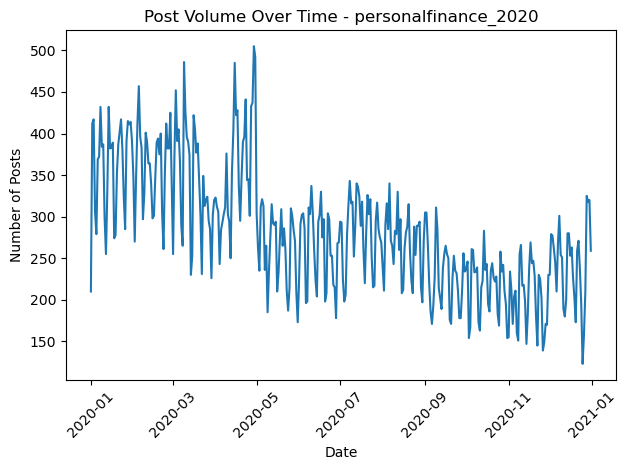

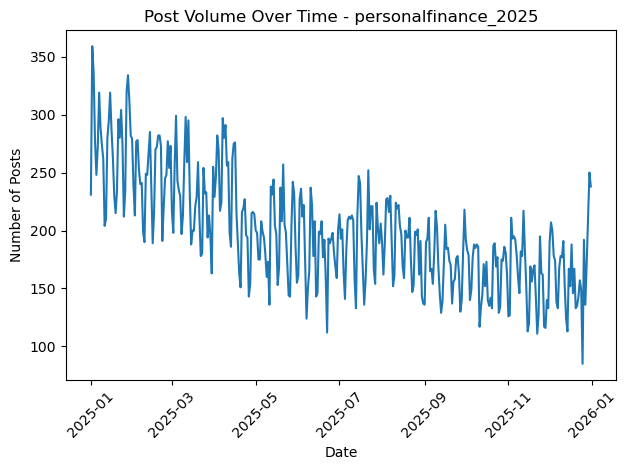

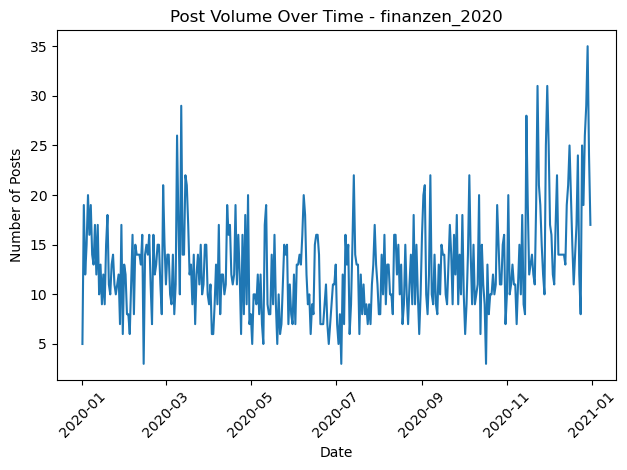

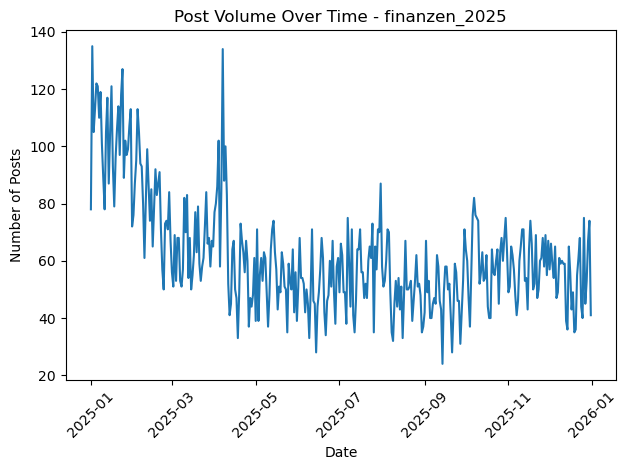

In [43]:
plot_post_volume(df_personalfinance_2020, "personalfinance_2020")
plot_post_volume(df_personalfinance_2025, "personalfinance_2025")
plot_post_volume(df_finanzen_2020, "finanzen_2020")
plot_post_volume(df_finanzen_2025, "finanzen_2025")

The post volume over time shows consistent patterns across all datasets, with no abrupt spikes or gaps that would indicate data collection issues. While gradual trends are observed, daily fluctuations remain within a reasonable range, suggesting stable and reliable data.

### Top-account audit

In [44]:
def top_account_audit(df, dataset_name, top_n=10):
    print(f"\n--- {dataset_name} ---")
    total_posts = len(df)
    # Count posts per user
    user_counts = df["author_fullname"].value_counts().head(top_n)
    # Convert to dataframe for easier handling
    audit_df = user_counts.reset_index()
    audit_df.columns = ["author_fullname", "post_count"]
    # Calculate percentage
    audit_df["percentage"] = (audit_df["post_count"] / total_posts) * 100
    # Print
    for _, row in audit_df.iterrows():
        print(f"{row['author_fullname']}: {row['post_count']} posts ({row['percentage']:.2f}%)")

In [45]:
top_account_audit(df_personalfinance_2020, "personalfinance_2020")
top_account_audit(df_personalfinance_2025, "personalfinance_2025")
top_account_audit(df_finanzen_2020, "finanzen_2020")
top_account_audit(df_finanzen_2025, "finanzen_2025")


--- personalfinance_2020 ---
t2_6l4z3: 77 posts (0.07%)
t2_3tncncsx: 54 posts (0.05%)
t2_pcq82: 44 posts (0.04%)
t2_ent2k: 43 posts (0.04%)
t2_46znvk0g: 42 posts (0.04%)
t2_1yuqce3a: 42 posts (0.04%)
t2_4brmhtd1: 40 posts (0.04%)
t2_zo32q: 34 posts (0.03%)
t2_4w8jjblc: 34 posts (0.03%)
t2_12kk3l: 31 posts (0.03%)

--- personalfinance_2025 ---
t2_1232bj: 107 posts (0.15%)
t2_27h0zm4r: 26 posts (0.04%)
t2_euwef: 16 posts (0.02%)
t2_wj5nl455s: 15 posts (0.02%)
t2_1tr0yaj5: 15 posts (0.02%)
t2_1f407i8u7w: 14 posts (0.02%)
t2_1fj2k2q53b: 14 posts (0.02%)
t2_yuec7t6bk: 14 posts (0.02%)
t2_1e9uncgh20: 14 posts (0.02%)
t2_1epbq7kmlt: 14 posts (0.02%)

--- finanzen_2020 ---
t2_6l4z3: 52 posts (1.12%)
t2_5s5dmwbz: 39 posts (0.84%)
t2_22dcitp5: 37 posts (0.80%)
t2_2hnztd9h: 32 posts (0.69%)
t2_4d418ye2: 30 posts (0.64%)
t2_3ka6r49t: 21 posts (0.45%)
t2_evkw7: 21 posts (0.45%)
t2_4zjm90fi: 20 posts (0.43%)
t2_5zmlrtrz: 16 posts (0.34%)
t2_2m05qk7u: 14 posts (0.30%)

--- finanzen_2025 ---
t2_fbpp7

No single user disproportionately dominates the datasets, indicating a balanced distribution of user activity.

### Text sample review

In [46]:
# Reset index for all cleaned datasets
df_personalfinance_2020 = df_personalfinance_2020.reset_index(drop=True)
df_personalfinance_2025 = df_personalfinance_2025.reset_index(drop=True)
df_finanzen_2020 = df_finanzen_2020.reset_index(drop=True)
df_finanzen_2025 = df_finanzen_2025.reset_index(drop=True)

In [47]:
index = 97

In [48]:
print(df_personalfinance_2020["text_for_sentiment"][index])

Help: What ever happened to that medical debt I never paid? Throwaway for obvious reasons. Back in 2017, I was hospitalized for a week at a time when I was uninsured. I was also out of work and had no way to afford the $20,000+ I now owed to the hospital. I panicked about repayments and, in my anxiety, decided to just entirely ignore the whopping bill. For a while, letters would get sent to my house on a regular basis with bills from the hospital. I opened them at first, and then stopped even reading them. I still have the unopened letters. Further, I just found one from a collections agency that was dated very early 2018 and said it was attempting to collect my debt from the hospital, and that I had 30 days to reply to their letter and set up a payment plan. Well, not proud of it, but fast forward 2 years since the collections letter, 2 and a half since the hospitalization and.....I never paid a cent of that medical debt. And have never been contacted by a collections agency, other th

In [49]:
print(df_personalfinance_2025["text_for_sentiment"][index])

Am I too conservative? My wife and I (early 30s) make $345k gross income in medium/highish cost of living area. We’ve only become higher earners in the past 3 years or so. Currently have just a $1700 mortgage on our starter home and need a bigger house as we have one young child in daycare and plan to have another. Since housing prices shot up a couple years ago, homes that are desirable to us are going for 800-850k. We have no other debt at the moment, but daycare is close to $2k/mo. Currently max out both 401ks and save an additional $4500 a month. Am I crazy for thinking we can’t afford a $850k house? We would be comfortable putting down about $275k which would leave a mortgage (including taxes and insurance) of about $4200 a month. I’ve just become very attached to saving a lot of money every month and having a hard time grappling with letting that go. We will also need a new/bigger care in the next few years, certainly once a 2nd child arrives. TIA!


In [50]:
print(df_finanzen_2020["text_for_sentiment"][index])

Dashboard für persönliche Finanzen Liebe [SUBREDDIT] community, ich beschäftige mich seit einiger Zeit mit dem Investieren und vor allem mit dem Thema Budget und Finanzplanung. Nachdem ich hier jetzt schon eine Weile nur mitlese wollte ich jetzt auch ein Mal etwas posten. In meiner Freizeit baue ich immer Mal wieder individuelle Excel-Spreadsheets und Dashboards für die persönliche Finanzplanung. Ich habe euch Mal ein kleines Beispiel angehängt, welches ich für eine weibliche Person (27) gebaut habe. Die Zahlen sind selbstverständlich völlig frei erfunden, Speisen sich aber aus unterliegenden Tabellen. Im Moment bin ich am überlegen ob ich Mal ein grundsätzliches Template baue. Gäbe es nach eurer Meinung nach überhaupt ein breiteres Interesse für so etwas? Naja, mal sehen. [URL]


In [51]:
print(df_finanzen_2025["text_for_sentiment"][index])

Notgroschen als Beamter? Ich habe mir einen Notgroschen in Höhe von 10.000€ zurückgelegt. Grundsätzlich spricht man ja von 3 mal das Monatsgehalt, da bin ich schon drüber. Ist diese Summe notwendig? Schließlich muss ich ( zum Glück) keinen Lohnausfall absichern ( hoffentlich). Somit bleiben evtl. Ersatzanschaffungen für Waschmaschine, und andere Geräte sowie eine evtl. Autoreparatur. Macht es eurer Meinung nach Sinn, 10.000€ dafür aufzuheben? Ansonsten kommt es in einen ETF.


A manual inspection of posts from all datasets confirms that the content is relevant, coherent, and consistent with the target domain. The texts reflect genuine user-generated discussions without signs of spam, bot activity, or off-topic content. Preprocessing steps preserved readability and semantic meaning, indicating that the cleaned datasets are suitable for downstream analysis.

# Download Final Datasets

In [52]:
df_personalfinance_2020.to_csv("personalfinance_2020_final.csv", index=False)
df_personalfinance_2025.to_csv("personalfinance_2025_final.csv", index=False)
df_finanzen_2020.to_csv("finanzen_2020_final.csv", index=False)
df_finanzen_2025.to_csv("finanzen_2025_final.csv", index=False)